# 📈 KEV Time Series Forecasting
**Goal:** Use KEV dataset to predict how many new exploited vulnerabilities CISA will add per month going forward.

This uses **ARIMA** — a standard forecasting model.

In [26]:
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from google.colab import files

print('Libraries loaded.')

Libraries loaded.


In [27]:
# Load data, auto-detect the date column, aggregate entries into monthly counts
uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0])

# Auto-detect the date column by name
date_col = None
for col in df.columns:
    if 'date' in col.lower() or 'added' in col.lower() or 'published' in col.lower():
        date_col = col
        break

if date_col is None:
    print('Could not find date column. Available columns:')
    print(df.columns.tolist())
    date_col = input('Enter the date column name: ')

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])

# Group entries by month — CISA KEV started Nov 2021 so we start from Jan 2021
monthly = df.set_index(date_col).resample('MS').size().rename('count')
monthly = monthly[monthly.index >= '2021-01-01']

print(f'Date column used: "{date_col}"')
print(f'Range: {monthly.index.min().strftime("%b %Y")} to {monthly.index.max().strftime("%b %Y")}')
print(f'Avg CVEs/month: {monthly.mean():.1f}')
print(monthly.head(6))

Saving sample.xlsx to sample (4).xlsx
Date column used: "Date Added"
Range: Nov 2021 to Mar 2026
Avg CVEs/month: 29.0
Date Added
2021-11-01    291
2021-12-01     20
2022-01-01     40
2022-02-01     32
2022-03-01    226
2022-04-01     45
Freq: MS, Name: count, dtype: int64


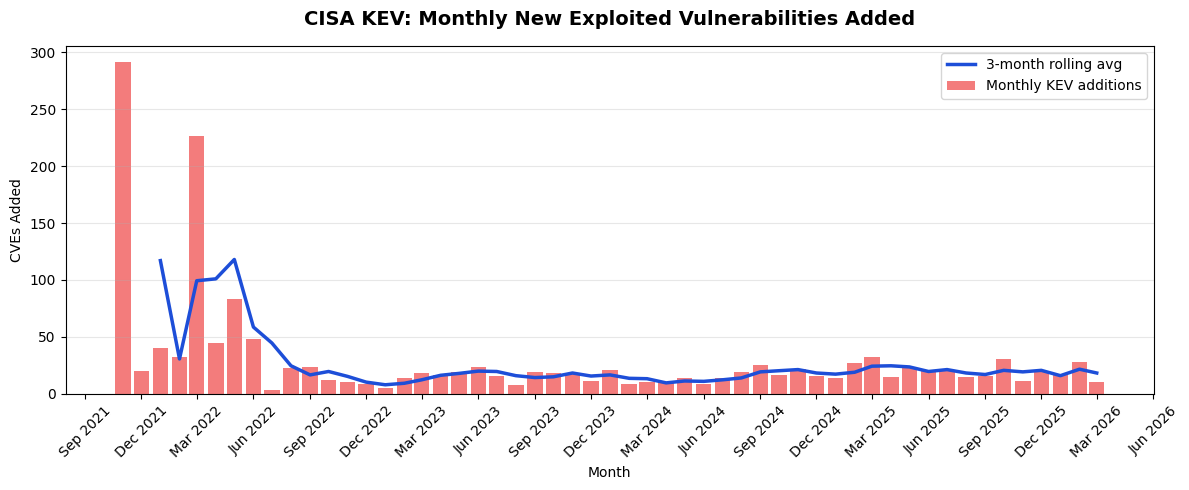

In [28]:
# Line + bar chart: historical monthly KEV additions with a 3-month rolling average
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(monthly.index, monthly.values, width=25, color='#ef4444', alpha=0.7, label='Monthly KEV additions')
ax.plot(monthly.index, monthly.rolling(3).mean(), color='#1d4ed8', linewidth=2.5, label='3-month rolling avg')

ax.set_title('CISA KEV: Monthly New Exploited Vulnerabilities Added', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('CVEs Added')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('kev_historical.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Cell 4: Fit ARIMA model
# ARIMA(p=2, d=1, q=2): good general-purpose settings for slowly-trending count data
# p=2  → uses last 2 months to predict next (autoregression)
# d=1  → one round of differencing to remove trend (makes series stationary)
# q=2  → corrects for last 2 forecast errors (moving average)

model = ARIMA(monthly, order=(2, 1, 2))
result = model.fit()

print('ARIMA(2,1,2) fitted.')
print(f'AIC: {result.aic:.1f}')
print(f'BIC: {result.bic:.1f}')
print(result.summary().tables[1])

ARIMA(2,1,2) fitted.
AIC: 548.1
BIC: 557.9
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9341      0.771     -1.211      0.226      -2.445       0.577
ar.L2          0.0269      0.698      0.039      0.969      -1.340       1.394
ma.L1          0.0317      0.701      0.045      0.964      -1.343       1.407
ma.L2         -0.5381      0.109     -4.920      0.000      -0.753      -0.324
sigma2      1770.9722    212.228      8.345      0.000    1355.014    2186.931


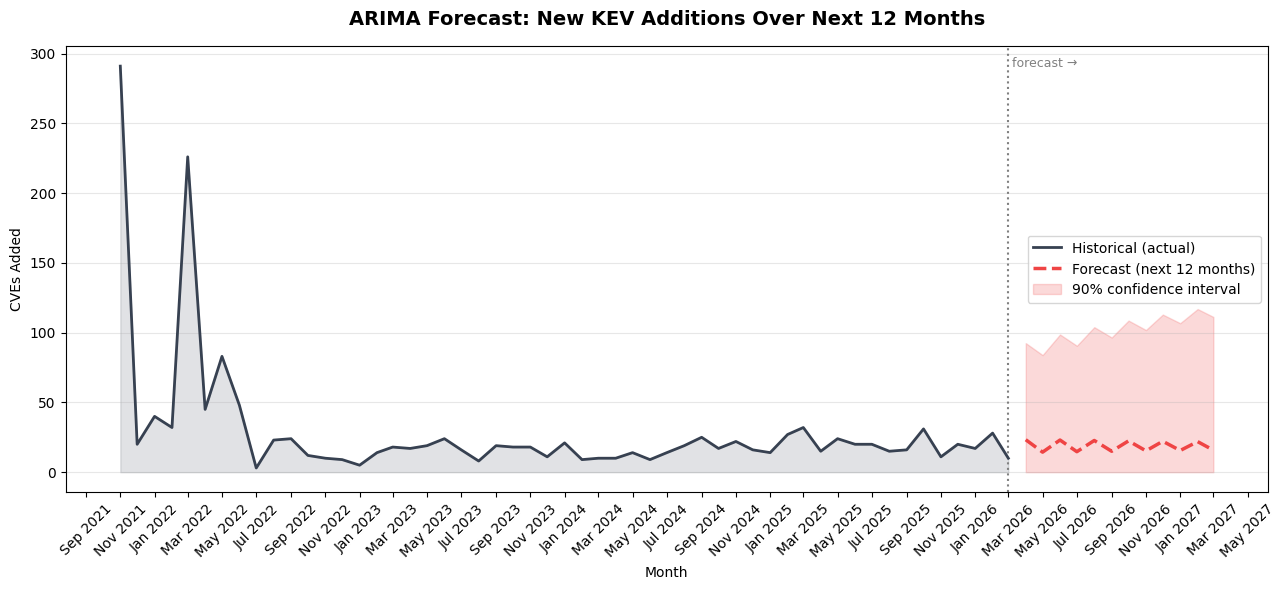

In [30]:
# Cell 5: Forecast next 12 months, plot against historical data with a 90% confidence band
steps = 12
forecast = result.get_forecast(steps=steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.10)  # 90% confidence interval

# Floor at 0 since negative CVE counts don't make sense
forecast_mean = forecast_mean.clip(lower=0)
conf_int = conf_int.clip(lower=0)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(monthly.index, monthly.values, color='#374151', linewidth=2, label='Historical (actual)', zorder=3)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#374151')

ax.plot(forecast_mean.index, forecast_mean.values, color='#ef4444', linewidth=2.5,
        linestyle='--', label='Forecast (next 12 months)', zorder=3)
ax.fill_between(forecast_mean.index,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                alpha=0.2, color='#ef4444', label='90% confidence interval')

ax.axvline(monthly.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.text(monthly.index[-1], ax.get_ylim()[1]*0.95, ' forecast →', fontsize=9, color='gray')

ax.set_title('ARIMA Forecast: New KEV Additions Over Next 12 Months', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('CVEs Added')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('kev_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Print summary stats: historical avg, peak month, forecast total, month-by-month breakdown
print('=' * 50)
print('PRESENTATION SUMMARY STATS')
print('=' * 50)
print(f'Historical range: {monthly.index.min().strftime("%b %Y")} – {monthly.index.max().strftime("%b %Y")}')
print(f'Historical avg/month: {monthly.mean():.1f} CVEs')
print(f'Historical peak: {monthly.max()} CVEs ({monthly.idxmax().strftime("%b %Y")})')
print(f'Forecast period: {forecast_mean.index[0].strftime("%b %Y")} – {forecast_mean.index[-1].strftime("%b %Y")}')
print(f'Forecasted avg/month: {forecast_mean.mean():.1f} CVEs')
print(f'Total predicted (12mo): {int(forecast_mean.sum())} CVEs')
print(f'90% CI lower: {int(conf_int.iloc[:, 0].sum())} | upper: {int(conf_int.iloc[:, 1].sum())}')
print('\nMonth-by-Month:')
for date, val, lo, hi in zip(forecast_mean.index, forecast_mean.values,
                              conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values):
    print(f'  {date.strftime("%b %Y"):>10}: {val:5.0f}  (CI: {lo:.0f} – {hi:.0f})')

PRESENTATION SUMMARY STATS
Historical range: Nov 2021 – Mar 2026
Historical avg/month: 29.0 CVEs
Historical peak: 291 CVEs (Nov 2021)
Forecast period: Apr 2026 – Mar 2027
Forecasted avg/month: 18.8 CVEs
Total predicted (12mo): 226 CVEs
90% CI lower: 0 | upper: 1224

Month-by-Month:
    Apr 2026:    23  (CI: 0 – 92)
    May 2026:    14  (CI: 0 – 84)
    Jun 2026:    23  (CI: 0 – 99)
    Jul 2026:    15  (CI: 0 – 91)
    Aug 2026:    23  (CI: 0 – 104)
    Sep 2026:    15  (CI: 0 – 97)
    Oct 2026:    22  (CI: 0 – 109)
    Nov 2026:    15  (CI: 0 – 102)
    Dec 2026:    22  (CI: 0 – 113)
    Jan 2027:    16  (CI: 0 – 107)
    Feb 2027:    22  (CI: 0 – 117)
    Mar 2027:    16  (CI: 0 – 111)
